# Explore the Zhuang-ABCA Dataset

Dataset: https://alleninstitute.github.io/abc_atlas_access/descriptions/zhuang-abca-3.html

Manuscript: https://www.nature.com/articles/s41586-023-06808-9

In [13]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

In [14]:
import pandas as pd

cells_abca_3 = pd.read_csv("data/zhuang-abca-3/cell_metadata.csv")
cells_abca_3

,cell_label,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id
0,198904341065180396762707397604803217407,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5252,5.128755,4.752046,1.230645,0.986932,0.982286,True,5c398479-67c8-42fe-befc-79a5f2641788
1,252199681526991424029643077826220097990,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5252,5.112333,4.745410,1.230645,0.928555,0.842943,True,f14d0b15-44d3-43ce-8e55-a40a76a78998
2,277720971126854564514249564750701518375,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5261,5.101224,4.722090,1.230645,0.921832,0.603301,True,fc94c5a9-2fe2-4cbd-8115-0d4a0e0921e6
3,31551867344111790264292067056219852271,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5258,5.105775,4.707346,1.230645,0.905368,0.905368,True,bf54e409-d3d4-44ca-9eb4-2b8933e73363
4,131102494428104399865219008178262036485,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5283,5.086307,4.569099,1.230645,0.999984,0.999984,True,67202afd-91c1-4205-a945-715365a5affd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585838,55192919491987647587752432952753516310,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5230,13.985773,6.493858,3.879380,0.999992,0.554346,True,f6ac1338-ec33-4c1e-b892-18a42566fdf1
1585839,5527365782112282574301502877997182927,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,4222,13.986354,6.576636,3.879380,0.942936,0.557775,True,1d305c5c-8d29-47b9-be56-31e2c0c71888
1585840,83562102707459388461009705694939129976,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,4333,13.995562,6.578075,3.879380,0.998942,0.998942,True,431de53d-8c9e-4c5b-bf01-a0d02653214c
1585841,84307656751549715453550812602843659096,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,14956,13.992428,6.504875,3.879380,0.999990,0.826865,True,fdcd633c-5102-417c-ab2f-b9557b9bf57c


In [15]:
import pandas as pd

ccf_3 = pd.read_csv("data/zhuang-abca-3/ccf_coordinates.csv")
ccf_3

,cell_label,x,y,z,parcellation_index
0,198904341065180396762707397604803217407,4.920685,4.487763,1.216815,887
1,252199681526991424029643077826220097990,4.897399,4.481376,1.217901,0
2,277720971126854564514249564750701518375,4.879107,4.457772,1.219271,0
3,31551867344111790264292067056219852271,4.883049,4.442612,1.219508,0
4,131102494428104399865219008178262036485,4.830884,4.302816,1.226788,0
...,...,...,...,...,...
1566837,318102106429791409781741726367984532777,13.109072,6.933427,4.143674,1087
1566838,35262847161560382172299767067854387528,13.121603,6.949407,4.135103,1087
1566839,75415866509570969932943497000463821106,13.141515,7.076450,4.080040,543
1566840,12350978322417280063239916106423065862,13.164617,7.118256,4.059599,0


In [16]:
# how many slices does zhuang-abca-3 contain? How many cells per sample?
# `abc_sample_id`: an individual sample (animal / batch / experiment)
# `brain_section_label`: a brain slice of one sample

print("How many slices does `zhuang-abca-3` contain? How many cells per slice?\n")
print(
    cells_abca_3["brain_section_label"]
    .value_counts()
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

How many slices does `zhuang-abca-3` contain? How many cells per slice?

count        23.000000
mean      68949.695652
std       34006.839257
min       10273.000000
1%        11150.140000
5%        14542.600000
10%       18084.200000
25%       41794.000000
50%       76615.000000
75%       95676.000000
90%      109321.400000
95%      116408.200000
99%      117069.380000
max      117074.000000
Name: count, dtype: float64


In [17]:
# how many brain sections does zhuang-abca-3 contain?


print(
    "How many brain sections does `zhuang-abca-3` contain? How many cells per brain section?\n"
)
print(
    ccf_3["parcellation_index"]
    .value_counts()
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

How many brain sections does `zhuang-abca-3` contain? How many cells per brain section?

count      647.000000
mean      2421.703246
std       5504.884071
min          2.000000
1%           9.300000
5%          33.300000
10%         66.000000
25%        249.000000
50%        779.000000
75%       2260.500000
90%       5509.000000
95%       9477.400000
99%      23714.820000
max      76931.000000
Name: count, dtype: float64


In [18]:
# given a brain section, how many samples include the section and how many cells are in this section per sample?
import pandas as pd

ccf_cell_3 = pd.merge(cells_abca_3, ccf_3, how="left", on="cell_label")
ccf_cell_3.groupby("parcellation_index")

print("Given a brain section, how many slices include the section?\n")
print(
    ccf_cell_3.groupby("parcellation_index")["brain_section_label"]
    .nunique()
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

Given a brain section, how many slices include the section?

count    647.000000
mean       5.539413
std        4.087803
min        1.000000
1%         1.000000
5%         1.000000
10%        2.000000
25%        3.000000
50%        4.000000
75%        7.000000
90%       11.000000
95%       15.000000
99%       19.000000
max       22.000000
Name: brain_section_label, dtype: float64


In [19]:
from NicheQueryPrototype.database import Database

parcellation_tree = Database().parse_parcellation_structure(
    json_path="data/parcellation/structure.json"
)
ccf_cell_3["parcellation_level"] = ccf_cell_3["parcellation_index"].map(
    lambda k: parcellation_tree.get(k, {}).get("st_level", -1)
)

s = ccf_cell_3.groupby(["parcellation_level", "parcellation_index"])[
    "brain_section_label"
].nunique()

print(
    "Given a brain section, how many slices include the section group by brain section level?\n"
)
print(
    s.groupby(level=0).describe(
        percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

Given a brain section, how many slices include the section group by brain section level?

                    count       mean        std   min     1%     5%   10%  \
parcellation_level                                                          
-1                   79.0   4.759494   4.188553   1.0   1.00   1.00   1.0   
 0                    1.0  10.000000        NaN  10.0  10.00  10.00  10.0   
 1                    4.0   6.750000   0.500000   6.0   6.03   6.15   6.3   
 2                    4.0   3.500000   0.577350   3.0   3.00   3.00   3.0   
 3                    2.0  10.000000  11.313708   2.0   2.16   2.80   3.6   
 5                    6.0   5.166667   4.167333   1.0   1.10   1.50   2.0   
 6                   21.0   6.142857   5.597193   1.0   1.00   1.00   1.0   
 7                   18.0   7.333333   4.537426   1.0   1.00   1.00   2.4   
 8                  171.0   5.368421   3.982158   1.0   1.00   1.00   1.0   
 9                  123.0   5.260163   3.591514   1.0   1.00   

In [20]:
s = ccf_cell_3.groupby(["parcellation_level"])["parcellation_index"].nunique()

print("# parcellations group by levels\n")
print(s)

# parcellations group by levels

parcellation_level
-1      79
 0       1
 1       4
 2       4
 3       2
 5       6
 6      21
 7      18
 8     171
 9     123
 10     32
 11    186
Name: parcellation_index, dtype: int64


In [21]:
s = ccf_cell_3.groupby(["parcellation_level", "parcellation_index"])[
    "cell_label"
].nunique()

print(
    "Given a brain section, how many cells in the brain section per brian slice group by brain section level?\n"
)
print(
    s.groupby(level=0).describe(
        percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

Given a brain section, how many cells in the brain section per brian slice group by brain section level?

                    count          mean          std      min        1%  \
parcellation_level                                                        
-1                   79.0   1205.721519  2869.004151      2.0      3.56   
 0                    1.0  30409.000000          NaN  30409.0  30409.00   
 1                    4.0   2261.000000  1214.302818    670.0    714.37   
 2                    4.0    973.500000   612.116819    339.0    350.49   
 3                    2.0   5233.000000  7329.868894     50.0    153.66   
 5                    6.0   1045.500000  1119.285978     36.0     50.65   
 6                   21.0   3793.904762  7740.466277     22.0     22.20   
 7                   18.0   4434.444444  6030.674952     25.0     34.35   
 8                  171.0   1934.725146  3002.390414      2.0      5.80   
 9                  123.0   3056.495935  6611.563461      2.0     12.

## Choose a parcellation for spot check

In [22]:
ccf_cell_3

,cell_label,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x_x,y_x,z_x,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,abc_sample_id,x_y,y_y,z_y,parcellation_index,parcellation_level
0,198904341065180396762707397604803217407,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5252,5.128755,4.752046,1.230645,0.986932,0.982286,True,5c398479-67c8-42fe-befc-79a5f2641788,4.920685,4.487763,1.216815,887.0,8
1,252199681526991424029643077826220097990,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5252,5.112333,4.745410,1.230645,0.928555,0.842943,True,f14d0b15-44d3-43ce-8e55-a40a76a78998,4.897399,4.481376,1.217901,0.0,-1
2,277720971126854564514249564750701518375,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5261,5.101224,4.722090,1.230645,0.921832,0.603301,True,fc94c5a9-2fe2-4cbd-8115-0d4a0e0921e6,4.879107,4.457772,1.219271,0.0,-1
3,31551867344111790264292067056219852271,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5258,5.105775,4.707346,1.230645,0.905368,0.905368,True,bf54e409-d3d4-44ca-9eb4-2b8933e73363,4.883049,4.442612,1.219508,0.0,-1
4,131102494428104399865219008178262036485,Zhuang-ABCA-3.023,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5283,5.086307,4.569099,1.230645,0.999984,0.999984,True,67202afd-91c1-4205-a945-715365a5affd,4.830884,4.302816,1.226788,0.0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585838,55192919491987647587752432952753516310,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,5230,13.985773,6.493858,3.879380,0.999992,0.554346,True,f6ac1338-ec33-4c1e-b892-18a42566fdf1,NaN,NaN,NaN,NaN,-1
1585839,5527365782112282574301502877997182927,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,4222,13.986354,6.576636,3.879380,0.942936,0.557775,True,1d305c5c-8d29-47b9-be56-31e2c0c71888,NaN,NaN,NaN,NaN,-1
1585840,83562102707459388461009705694939129976,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,4333,13.995562,6.578075,3.879380,0.998942,0.998942,True,431de53d-8c9e-4c5b-bf01-a0d02653214c,NaN,NaN,NaN,NaN,-1
1585841,84307656751549715453550812602843659096,Zhuang-ABCA-3.009,Zhuang-ABCA-3,Zhuang-ABCA-3,wt/wt,M,14956,13.992428,6.504875,3.879380,0.999990,0.826865,True,fdcd633c-5102-417c-ab2f-b9557b9bf57c,NaN,NaN,NaN,NaN,-1


In [23]:
ccf_cell_3.donor_label.nunique()

1

In [24]:
# random select a parcellation & sample

# step 1: print parcellation at a specific level # 987
target_parcellations = ccf_cell_3[ccf_cell_3["parcellation_level"] == 6][
    "parcellation_index"
].unique()
print(f"Check parcellation at level 6: {target_parcellations}")

Check parcellation at level 6: [ 467.  485.  987.  645. 1073. 1080.  856.  818.  864.  339.  141.  500.
  157.  809.  278.  348.  323.  669.  370.  822.  541.]


In [25]:
# random select a parcellation & sample

# step 1: print parcellation at a specific level
target_parcellations = ccf_cell_3[ccf_cell_3["parcellation_level"] == 5][
    "parcellation_index"
].unique()
print(f"Check parcellation at level 5: {target_parcellations}")

Check parcellation at level 5: [ 771.  315.  549. 1097.  528.  354.]


In [28]:
# step 2: check # samples with this parcellation
target_parcellation = 207

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    None,
    "display.max_colwidth",
    None,
):
    s = ccf_cell_3[ccf_cell_3["parcellation_index"] == target_parcellation][
        "brain_section_label"
    ].value_counts()
    print(
        f"Samples with this parcellation & # cells in this parcellation per sample: \n{s}"
    )
    print(
        f"Total samples: {s.shape[0]} out of {ccf_cell_3['brain_section_label'].nunique()}"
    )

Samples with this parcellation & # cells in this parcellation per sample: 
brain_section_label
Zhuang-ABCA-3.004    596
Zhuang-ABCA-3.003    533
Zhuang-ABCA-3.005    409
Zhuang-ABCA-3.002    224
Zhuang-ABCA-3.001     52
Name: count, dtype: int64
Total samples: 5 out of 23


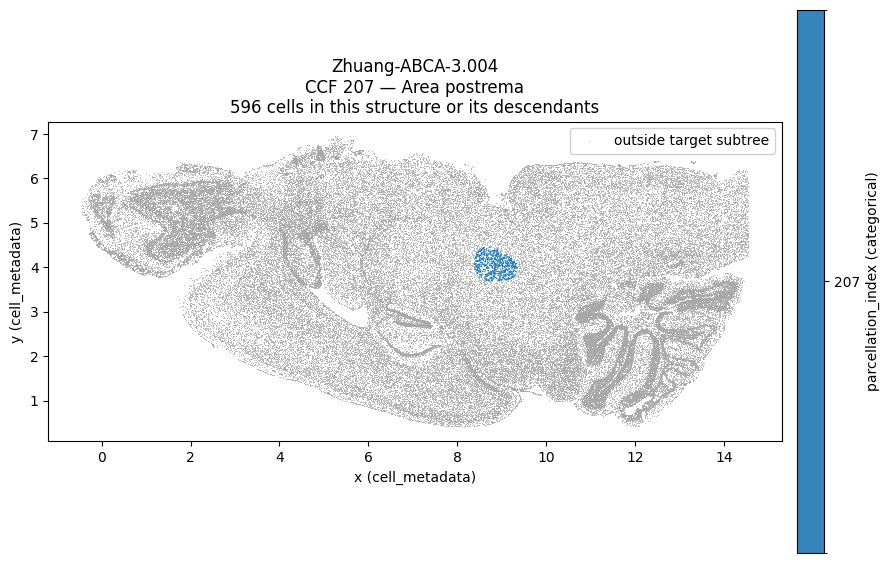

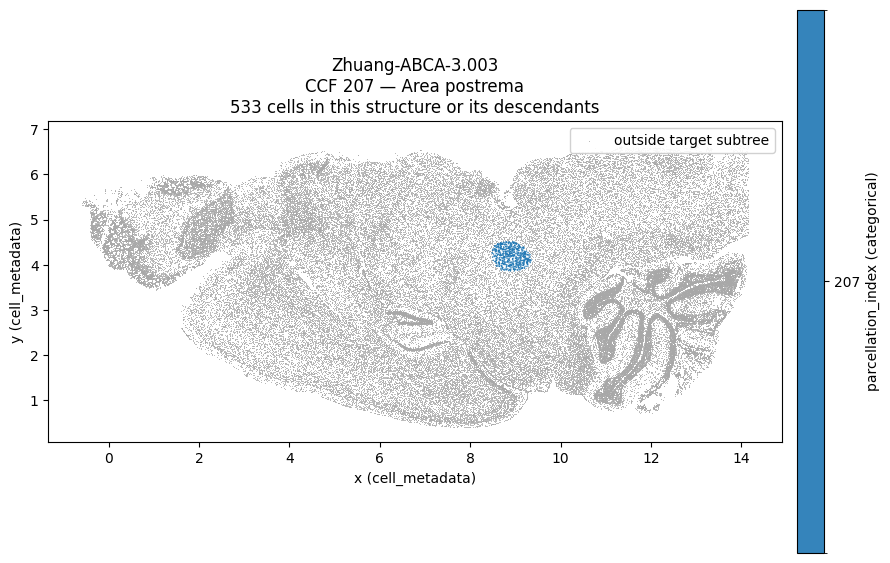

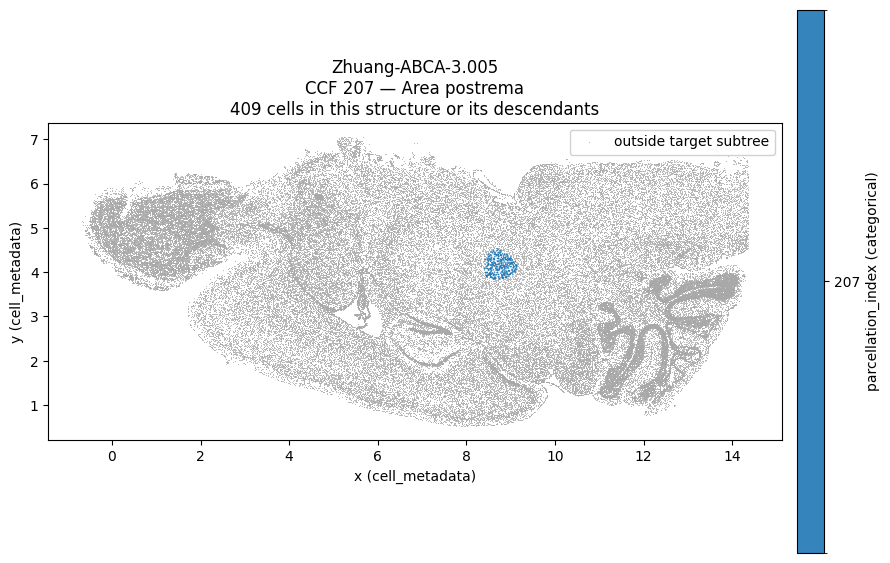

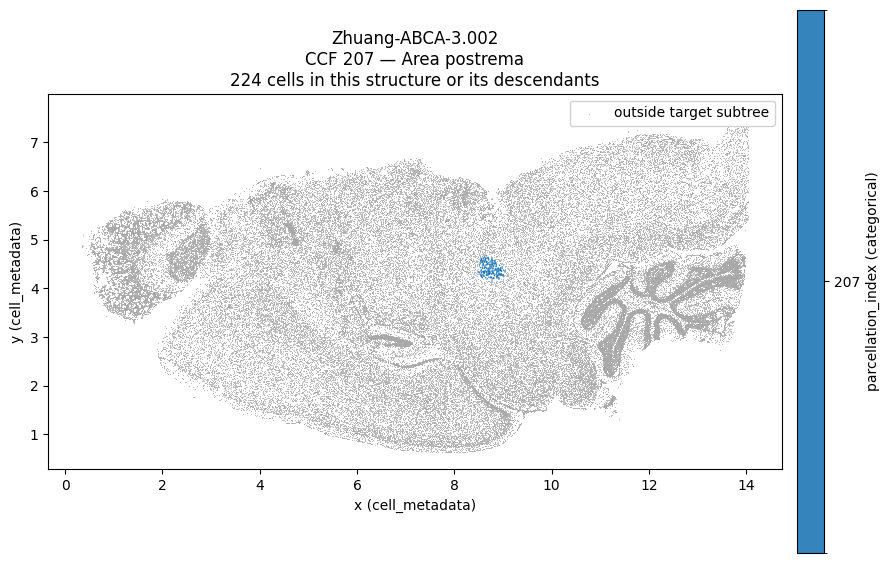

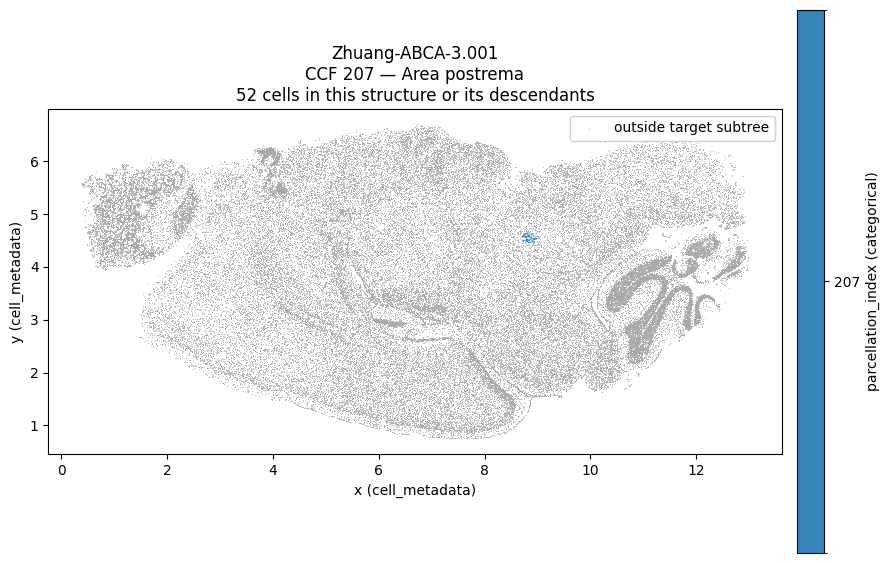

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap


def visualize_parcellation_subtree_on_section(
    df,
    parcellation_tree,
    brain_section_label,
    parcellation_index,
    *,
    x_col="x_x",
    y_col="y_x",
    section_col="brain_section_label",
    parc_col="parcellation_index",
    figsize=(9, 9),
    show=True,
):
    """Plot one brain section using cell_metadata x/y (default ``x_x`` / ``y_x`` after merge).

    Cells outside the target subtree are light gray. Descendant ``parcellation_index`` values are
    colored by **category** (IDs are arbitrary, not a continuous scale).

    Returns ``(fig, ax)``.
    """

    def _cell_in_subtree(pid, root_id, tree):
        if pd.isna(pid):
            return False
        info = tree.get(int(pid), {})
        return root_id in (info.get("parent_ids") or set())

    root_id = int(parcellation_index)
    sec = df[df[section_col] == brain_section_label]
    if sec.empty:
        raise ValueError(f"No cells for brain_section_label={brain_section_label!r}")

    sub_mask = sec[parc_col].map(
        lambda p: _cell_in_subtree(p, root_id, parcellation_tree)
    )
    hl = sec.loc[sub_mask].copy()

    region_name = parcellation_tree.get(root_id, {}).get("name", "?")
    fig, ax = plt.subplots(figsize=figsize)

    other = sec.loc[~sub_mask]
    if not other.empty:
        ax.scatter(
            other[x_col],
            other[y_col],
            s=0.45,
            c="#a8a8a8",
            alpha=0.75,
            linewidths=0,
            rasterized=True,
            label="outside target subtree",
        )

    if hl.empty:
        ax.set_title(
            f"{brain_section_label}\nNo cells under CCF id {root_id} ({region_name})"
        )
        if not other.empty:
            ax.legend(loc="upper right", framealpha=0.9)
    else:
        hl["pid"] = hl[parc_col].astype(int)
        uniq = np.sort(hl["pid"].unique())
        n = len(uniq)
        pid_to_code = {p: i for i, p in enumerate(uniq)}
        codes = hl["pid"].map(pid_to_code).to_numpy(dtype=float)

        tab20 = plt.cm.tab20(np.linspace(0, 1, 20, endpoint=False))
        tab20b = plt.cm.tab20b(np.linspace(0, 1, 20, endpoint=False))
        set3 = plt.cm.Set3(np.linspace(0, 1, 12, endpoint=False))
        pal = np.vstack([tab20, tab20b, set3])
        colors = [pal[i % len(pal)] for i in range(n)]
        cmap = ListedColormap(colors)
        bounds = np.arange(n + 1) - 0.5
        norm = BoundaryNorm(bounds, cmap.N)

        sc = ax.scatter(
            hl[x_col],
            hl[y_col],
            c=codes,
            cmap=cmap,
            norm=norm,
            s=1.2,
            alpha=0.9,
            linewidths=0,
        )
        cbar = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02, ticks=np.arange(n))
        cbar.ax.set_yticklabels([str(u) for u in uniq])
        cbar.set_label("parcellation_index (categorical)")

        if not other.empty:
            ax.legend(loc="upper right", framealpha=0.9)

        ax.set_title(
            f"{brain_section_label}\nCCF {root_id} — {region_name}\n"
            f"{len(hl):,} cells in this structure or its descendants"
        )

    ax.set_xlabel("x (cell_metadata)")
    ax.set_ylabel("y (cell_metadata)")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax


target_sample_ids = [
    "Zhuang-ABCA-3.004",
    "Zhuang-ABCA-3.003",
    "Zhuang-ABCA-3.005",
    "Zhuang-ABCA-3.002",
    "Zhuang-ABCA-3.001",
]
for sample_id in target_sample_ids:
    visualize_parcellation_subtree_on_section(
        ccf_cell_3,
        parcellation_tree,
        brain_section_label=sample_id,
        parcellation_index=target_parcellation,
    )